# Initial Imports and Constants

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.optimize import least_squares
from numpy.linalg import inv


In [63]:
tess_offset = 2457000

In [64]:
bootstrap = True

# Get Data

In [4]:
### Planet params 
per_2=  28.579889 #28.579743
rp_2= 0.0312382795966642 #0.03118
b_2=  0.482378819760311 #0.630
T14_2= 4.47016349523855 * 0.0416667    #4.162 * 0.0416667  # convert to days from hours 


In [5]:
# planet b
per_3=  38.352562 #38.353037
rp_3=  0.0305954481349672 #0.02916
b_3=  0.323085496752003 #0.440
T14_3= 5.51199861214238 * 0.0416667 #5.36 * 0.0416667  # convert to days from hours (from Gunther et al 2019)


In [65]:
if bootstrap == True:
    # bootstrap method
    df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
else:
    # no bootstrap method (chisq +1)
    df = pd.read_csv("toi_1339_transit_data_all_no_bootstrap.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_14948/131908810.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])
/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_14948/131908810.py:6: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("toi_1339_transit_data_all_no_bootstrap.txt", sep="\s+", header=0, names=['Planet_num', 'Index', 'Tc', 'Tc_err'])


In [66]:
print(df)

    Planet_num  Index           Tc    Tc_err
0            2      0  1726.054868  0.002238
1            2      1  1754.633366  0.001001
2            2      2  1783.211863  0.001416
3            2      3  1811.799370  0.003165
4            2      4  1840.374865  0.001001
5            2      6  1897.535865  0.002238
6            2      7  1926.116366  0.001416
7            2     25  2440.545345  0.002002
8            2     32  2640.606843  0.001416
9            2     34  2697.771847  0.001416
10           2     35  2726.353348  0.002238
11           2     38  2812.096850  0.004127
12           2     39  2840.673346  0.001416
13           2     42  2926.419851  0.002238
14           2     55  3297.970355  0.002831
15           2     57  3355.129353  0.001416
16           2     58  3383.711855  0.001001
17           2     60  3440.876859  0.001416
18           2     64  3555.194855  0.002238
19           2     65  3583.772352  0.001533
20           2     66  3612.349849  0.001416
21        

In [67]:
indices_2 = df[df['Planet_num'] == 2]['Index'].tolist()
transit_times_2 = df[df['Planet_num'] == 2]['Tc'].tolist()
tc_err_2 = df[df['Planet_num'] == 2]['Tc_err'].tolist()

indices_3 = df[df['Planet_num'] == 3]['Index'].tolist()
transit_times_3 = df[df['Planet_num'] == 3]['Tc'].tolist()
tc_err_3 = df[df['Planet_num'] == 3]['Tc_err'].tolist()


# OMC

In [68]:
# Define linear ephemeris function
def linear_ephem(E, T0, P):
    return T0 + P * E

# Function to compute O-C per planet
def compute_oc(df):
    df_all = []
    fit_params = []  # store fit results here

    for planet in df['Planet_num'].unique():
        planet_df = df[df['Planet_num'] == planet].copy()
        E = planet_df['Index'].values
        Tc_obs = planet_df['Tc'].values
        Tc_err = planet_df['Tc_err'].values

        # Fit linear ephemeris
        popt, pcov = curve_fit(linear_ephem, E, Tc_obs, sigma=Tc_err, absolute_sigma=True)
        T0, P = popt
        T0_err, P_err = np.sqrt(np.diag(pcov))

        Tc_calc = linear_ephem(E, T0, P)
        oc = Tc_obs - Tc_calc

        planet_df['Tcalc'] = Tc_calc
        planet_df['O-C'] = oc
        planet_df['Planet'] = planet
        df_all.append(planet_df)

        fit_params.append({
            'Planet_num': planet,
            'T0': T0,
            'T0_err': T0_err,
            'Period': P,
            'Period_err': P_err
        })

    return pd.concat(df_all), pd.DataFrame(fit_params)


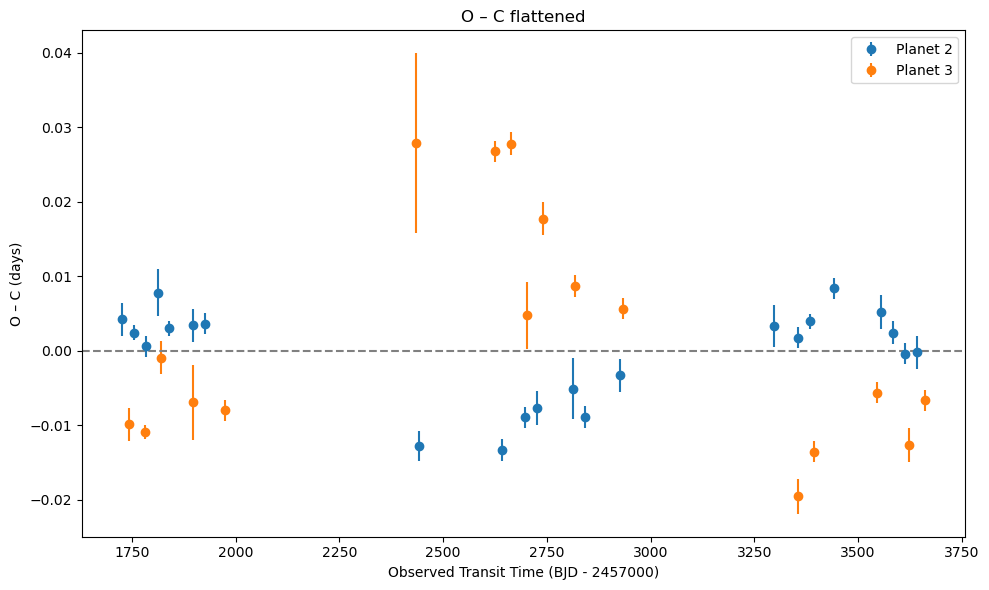

In [69]:
df_oc, ephem_df = compute_oc(df)

# Plot: O–C vs. Tc_obs for all planets
plt.figure(figsize=(10, 6))
for planet in df_oc['Planet_num'].unique():
    subset = df_oc[df_oc['Planet_num'] == planet]
    plt.errorbar(
        subset['Tc'], subset['O-C'], yerr=subset['Tc_err'],
        fmt='o', label=f'Planet {planet}'
    )

plt.axhline(0, color='gray', linestyle='--')
plt.xlabel(f"Observed Transit Time (BJD - {tess_offset})")
plt.ylabel("O – C (days)")
plt.title("O – C flattened")
plt.legend()
plt.tight_layout()
plt.show()

# Single Harmonic Sine Fit

In [70]:
### from Lithwick et al. 2012
### TTV period 
def ttv_per(P2, j, delta):
    P12 = P2 / (j*np.abs(delta))
    return P12

def delta_(P1, P2, j):
    d = ((P2/P1)*((j-1)/j)) - 1
    return d


In [71]:
print(ephem_df)


   Planet_num           T0    T0_err     Period  Period_err
0           2  1726.050653  0.000536  28.580297    0.000013
1           3  1743.563161  0.000702  38.351415    0.000023


In [72]:
j = 4 # 4:3 MMR
p_2 = ephem_df['Period'][0]
p_3 = ephem_df['Period'][1]
tc_2 = ephem_df['T0'][0]
tc_3 = ephem_df['T0'][1]


delta = delta_(p_2, p_3, j)
print(f'delta: {delta}')

ttv_period = ttv_per(p_3, j, delta)
print(f'TTV period: {ttv_period} days')

delta: 0.006412261215312132
TTV period: 1495.2375439378668 days


In [73]:
def ttv_amp_1(P1, m2, m_star, j, delta, f, Z):
    term1_num = m2/m_star
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = -f - ((3*Z)/(2*delta))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def ttv_amp_2(P2, m1, m_star, j, delta, g, Z):
    term1_num = m1/m_star
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 = -g - ((3*Z)/2*delta)
    ttv_amp = P2 * term1 * term2
    return ttv_amp

In [74]:
def model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0))


def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = params

    ### define models
    t_model_b = model_b(i_b, t_b0, P_b, A_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, P_cb, t_cb0)

    ### find residuals
    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])


In [75]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###

initial_params = [initial_t_b0, initial_P_b, initial_A_bc, initial_t_c0, 
                  initial_P_c, initial_A_cb, initial_P_cb, initial_t_cb0]


In [76]:
from scipy.optimize import least_squares

indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)

indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)


### Run the fit (fitting residuals)
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

fitted_params = result.x
print(fitted_params)

### unpack fit params
t_b0, P_b, A_bc, t_c0, P_c, A_cb, P_cb, t_cb0 = fitted_params

[ 1.72604551e+03  2.85803324e+01  8.06112110e-03  1.74357240e+03
  3.83512528e+01 -1.89251097e-02  1.55312085e+03  1.39446550e+03]


In [77]:
from numpy.linalg import inv
### errors on fit 
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, t_c0_err, P_c_err, A_cb_err, P_cb_err, t_cb0_err = param_errors

In [78]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "t_c0", "P_c", "A_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04551494 ± 0.00063209
   P_b = 28.58033237 ± 0.00001413
  A_bc = 0.00806112 ± 0.00049204
  t_c0 = 1743.57239877 ± 0.00088785
   P_c = 38.35125277 ± 0.00003187
  A_cb = -0.01892511 ± 0.00069304
  P_cb = 1553.12085206 ± 31.72147893
 t_cb0 = 1394.46549764 ± 33.94152270


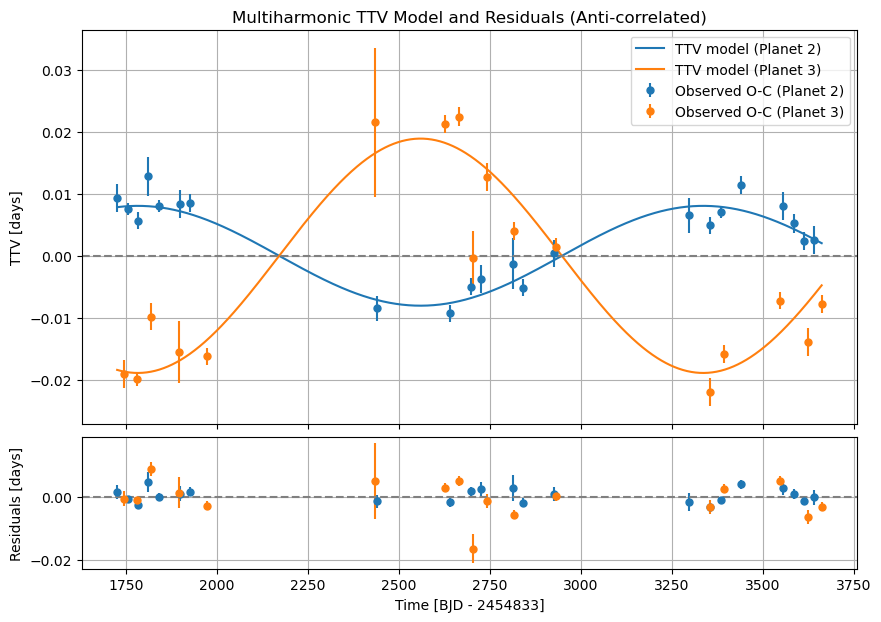

In [79]:
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0)) #* 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0)) #* 1440  

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) #* 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) #* 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0)) #* 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0)) #* 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [days]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [days]")
ax2.grid(True)

plt.show()

In [80]:
print('Predicted values from Lubin et al 2022:')
print('predicted P_23: 1490 ± 10 days')
print('predicted A_23: 15.5 ± 9.1 min')
print('predicted A_32: 59.2 ± 13.8 min')
print('Multi-harmonic fit values:')
print(f'P_23: {np.round(P_cb,6)} ± {np.round(P_cb_err,6)} days')
print(f'A_bc: {np.round(A_bc,6)*1440} ± {np.round(A_bc_err,6)*1440} min')
print(f'A_cb: {np.round(A_cb,6)*1440} ± {np.round(A_cb_err,6)*1440} min')

Predicted values from Lubin et al 2022:
predicted P_23: 1490 ± 10 days
predicted A_23: 15.5 ± 9.1 min
predicted A_32: 59.2 ± 13.8 min
Multi-harmonic fit values:
P_23: 1553.120852 ± 31.721479 days
A_bc: 11.607840000000001 ± 0.70848 min
A_cb: -27.252000000000002 ± 0.99792 min


# Save Data

In [81]:
import pickle

# Bundle all relevant data into a dictionary
ttv_data = {
    "tc_lin_obs_2": t_lin_obs_b,
    "tc_lin_obs_3": t_lin_obs_c,
    "omc_2": oc_b,
    "omc_3": oc_c,
    "ttv_model_2": ttv_model_b,
    "ttv_model_3": ttv_model_c,
    "residuals_2": residuals_b,
    "residuals_3": residuals_c,
    "tc_err_2": np.array(tc_err_2),
    "tc_err_3": np.array(tc_err_3),
    "indices_2": np.array(indices_2),
    "indices_3": np.array(indices_3),
    "t_dense": np.array(t_dense),
    "ttv_2": np.array(ttv_b),
    "ttv_3": np.array(ttv_c)
}

if bootstrap == True:
    # Save to a file
    with open("1339_sine_fit.pkl", "wb") as f:
        pickle.dump(ttv_data, f)

else:
    # Save to a file
    with open("1339_sine_fit_no_bootstrap.pkl", "wb") as f:
        pickle.dump(ttv_data, f)


# Following V1298Tau
procedure for planets b and e, where L12 applies

# Try fitting sine with phase

In [82]:
def P_ttv_(P2, j, Delta):
    P = P2 / (j*np.abs(Delta))
    return P

def A_1_(P1, mu2, j, delta, f1, Z):
    term1_num = mu2
    term1_den = np.pi * j**(2./3.) * (j-1)**(1./3.) * delta
    term1 = term1_num / term1_den
    term2 = (-f1 - ((3*Z.conjugate())/(2*delta)))
    ttv_amp = P1 * term1 * term2
    return ttv_amp

def A_2_(P2, mu1, j, delta, f2, Z):
    term1_num = mu1
    term1_den = np.pi * j * delta
    term1 = term1_num / term1_den
    term2 =(-f2 + ((3*Z.conjugate())/(2*delta)))
    ttv_amp = P2 * term1 * term2
    return ttv_amp

def Z_free(f1,f2,z_free1, z_free2):
    Z = f1*z_free1 + f2*z_free2
    return Z

def z_k(e_k, pomega_k):
    z = e_k*np.cos(pomega_k) + 1j*e_k*np.sin(pomega_k)
    return z

def semimajor_axis(P, M_star, G_const):
    return (G_const * M_star * (P/(2*np.pi))**2) ** (1/3)


In [83]:
def model_b(i_b, t_b0, P_b, A_bc, phi_b, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    return t_linear + A_bc * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0) + phi_b)


def model_c(i_c, t_c0, P_c, A_cb, phi_c, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    return t_linear + A_cb * np.sin((2 * np.pi / P_cb) * (t_linear - t_cb0) + phi_c)

def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, A_bc, phi_b, t_c0, P_c, A_cb, phi_c, P_cb, t_cb0 = params

    t_model_b = model_b(i_b, t_b0, P_b, A_bc, phi_b, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, A_cb, phi_c, P_cb, t_cb0)

    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])

In [84]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###
initial_phi_b = 0.0
initial_phi_c = 0.0



initial_params = [
    initial_t_b0, initial_P_b, initial_A_bc, initial_phi_b,
    initial_t_c0, initial_P_c, initial_A_cb, initial_phi_c,
    initial_P_cb, initial_t_cb0
]

In [85]:

indices_2 = np.array(indices_2)
transit_times_2 = np.array(transit_times_2)
tc_err_2 = np.array(tc_err_2)

indices_3 = np.array(indices_3)
transit_times_3 = np.array(transit_times_3)
tc_err_3 = np.array(tc_err_3)


In [86]:
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

In [87]:
fitted_params = result.x
t_b0, P_b, A_bc, phi_b, t_c0, P_c, A_cb, phi_c, P_cb, t_cb0 = result.x


In [88]:
from numpy.linalg import inv

# Covariance matrix estimate
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, A_bc_err, phi_b_err, t_c0_err, P_c_err, A_cb_err, phi_c_err, P_cb_err, t_cb0_err = param_errors


In [89]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "A_bc", "phi_b", "t_c0", "P_c", "A_cb", "phi_c", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04577366 ± 0.00067116
   P_b = 28.58032669 ± 0.00001463
  A_bc = 0.00779705 ± 0.00052138
 phi_b = -13.28471593 ± 222.81612121
  t_c0 = 1743.57258262 ± 0.00100515
   P_c = 38.35124711 ± 0.00003477
  A_cb = -0.01913176 ± 0.00088262
 phi_c = -13.15713029 ± 222.79480202
  P_cb = 1552.30976250 ± 31.87803907
 t_cb0 = -1860.45785159 ± 55062.68531695


In [90]:
import numpy as np

def compute_ttv_phase_shift(A1, phi1, A2, phi2):
    """
    Compute the observed TTV phase difference between two planets.

    Parameters
    ----------
    A1 : float
        Amplitude of the first planet's TTV (e.g., inner planet)
    phi1 : float
        Phase of the first planet's TTV [radians]
    A2 : float
        Amplitude of the second planet's TTV (e.g., outer planet)
    phi2 : float
        Phase of the second planet's TTV [radians]

    Returns
    -------
    phi_obs : float
        Phase difference phi2 - phi1 wrapped to [-π, π] (radians)
    """

    # If amplitudes can be negative, take absolute value to match paper convention
    A1 = np.abs(A1)
    A2 = np.abs(A2)

    # Convert to complex numbers representing TTV vectors
    Z1 = A1 * np.exp(1j * phi1)
    Z2 = A2 * np.exp(1j * phi2)

    # Compute phase difference
    phi_obs = np.angle(Z2 / Z1)  # effectively phi2 - phi1

    # Wrap to [-π, π]
    phi_obs = (phi_obs + np.pi) % (2 * np.pi) - np.pi

    return phi_obs

# Example usage with your fitted parameters
phi_obs = compute_ttv_phase_shift(A_bc, phi_b, A_cb, phi_c)
print(f"Observed phase difference: {phi_obs:.4f} rad")


Observed phase difference: 0.1276 rad


In [91]:
# Compute observed phase difference
phi_obs = phi_c - phi_b
phi_obs = (phi_obs + np.pi) % (2 * np.pi) - np.pi  # wrap to [-π, π]

# Indices of phi_b and phi_c
i_phi_b = 3
i_phi_c = 7

sigma_phi_b = np.sqrt(cov[i_phi_b, i_phi_b])
sigma_phi_c = np.sqrt(cov[i_phi_c, i_phi_c])
cov_phi = cov[i_phi_b, i_phi_c]

### error propagation for correlated params
sigma_phi_obs = np.sqrt(sigma_phi_b**2 + sigma_phi_c**2 - 2 * cov_phi)

print(f"φ_obs = {phi_obs:.4f} ± {sigma_phi_obs:.4f} rad")


φ_obs = 0.1276 ± 0.1187 rad


In [92]:
phase_shift = ((2*np.pi)/(P_cb))*t_cb0
phase_shift_wrap = (phase_shift + np.pi) % (2 * np.pi) - np.pi
print(phase_shift_wrap)

print(np.radians(((2*np.pi)/(2852))*2239))

-1.2472713839340717
0.08609180401293078


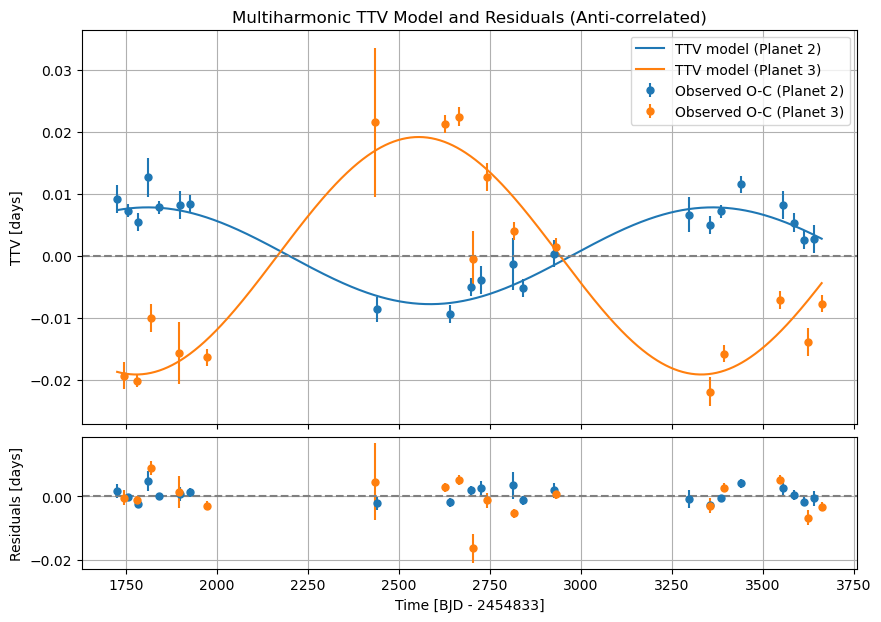

In [93]:
from matplotlib.gridspec import GridSpec
# Combine observed times to set the time range
all_times = np.concatenate([transit_times_2, transit_times_3])
t_dense = np.linspace(np.min(all_times), np.max(all_times), 1000)

# Compute "virtual" transit indices for continuous times
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c

# Linear ephemerides
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# Anti-correlated TTV signals: negate one amplitude!
ttv_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_b - t_cb0) + (phi_b)) #* 1440
ttv_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_c - t_cb0) + (phi_c)) #* 1440  

# Observed linear ephemerides
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)

# Observed O-C residuals in minutes
oc_b = (np.array(transit_times_2) - t_lin_obs_b) #* 1440
oc_c = (np.array(transit_times_3) - t_lin_obs_c) #* 1440


# Predict TTV model at observed times (for residuals)
ttv_model_b = A_bc * np.sin((2 * np.pi / P_cb) * (t_lin_obs_b - t_cb0) + (phi_b)) #* 1440
ttv_model_c = A_cb * np.sin((2 * np.pi / P_cb) * (t_lin_obs_c - t_cb0) + (phi_c)) #* 1440

# Residuals: (observed O-C) - (model TTV)
residuals_b = oc_b - ttv_model_b
residuals_c = oc_c - ttv_model_c

# Plot with subpanels: main TTV + residuals
fig = plt.figure(figsize=(10, 7))
gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# TTV Model and Observations
ax1 = fig.add_subplot(gs[0])

ax1.plot(t_dense, ttv_b, label="TTV model (Planet 2)", color='tab:blue')
ax1.plot(t_dense, ttv_c, label="TTV model (Planet 3)", color='tab:orange')

ax1.errorbar(t_lin_obs_b, oc_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', label='Observed O-C (Planet 2)', markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', label='Observed O-C (Planet 3)', markersize=5)

ax1.axhline(0, color='gray', linestyle='--')
ax1.set_ylabel("TTV [days]")
ax1.set_title("Multiharmonic TTV Model and Residuals (Anti-correlated)")
ax1.tick_params(labelbottom=False) 
ax1.legend()
ax1.grid(True)

# Residuals Panel
ax2 = fig.add_subplot(gs[1], sharex=ax1)

ax2.errorbar(t_lin_obs_b, residuals_b, yerr=np.array(tc_err_2), fmt='o',
             color='tab:blue', markersize=5, label="Residuals (b)")
ax2.errorbar(t_lin_obs_c, residuals_c, yerr=np.array(tc_err_3), fmt='o',
             color='tab:orange', markersize=5, label="Residuals (c)")

ax2.axhline(0, color='gray', linestyle='--')
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [days]")
ax2.grid(True)

plt.show()

In [94]:
k=4
f1 = -2.840
f2 = 3.283
M_star = 0.81 # [solar mass]

from astropy.constants import G, M_sun
from astropy import units as u

# Gravitational constant in AU^3 / (Msun * day^2)
G_au = G.to(u.AU**3 / (u.M_sun * u.day**2))
G_const = G_au.value


In [95]:
np.random.seed(42)

def log_uniform(low, high, size=None):
    return 10 ** np.random.uniform(np.log10(low), np.log10(high), size=size)

def uniform(low, high, size=None):
    return np.random.uniform(low, high, size=size)


In [96]:
P_ttv_obs = P_cb
sigma_P_ttv = P_cb_err
A1_obs = np.abs(A_bc)
sigma_A1 = A_bc_err
A2_obs = np.abs(A_cb)
sigma_A2 = A_cb_err
P1 = P_b
P2 = P_c
print(A1_obs)
print(A2_obs)
# calculate phase shift

sigma_phi =sigma_phi_obs
print(f"ϕ = {phi_obs:.3f} ± {sigma_phi:.3f} radians")

delta = delta_(P1, P2, k)
print(f'delta: {delta}')

0.007797054168990911
0.01913175531762013
ϕ = 0.128 ± 0.119 radians
delta: 0.006406807146134508


In [97]:
N_samples = int(1e6) 

In [98]:
mu1 = log_uniform(3e-6, 9e-5, N_samples)               # planet/star mass ratio
m2_m1 = log_uniform(0.1, 2, N_samples)                 # mass ratio m2/m1
mu2 = mu1 * m2_m1                                     # mass ratio for planet 2

Z_mag = log_uniform(1e-4, 1e-1, N_samples)             # magnitude of Z_free
Z_phase = np.random.uniform(0, 2*np.pi, N_samples)    # phase of Z_free

Z_free = Z_mag * np.exp(1j * Z_phase)


In [99]:
# Compute simulated complex amplitudes (L12 formalism)
# A1_sim_complex = (P1 * mu2 / (np.pi * j**(2/3) * (j - 1)**(1/3) * delta)) * (-f1 * np.conj(Z_free) / delta)
# A2_sim_complex = (P2 * mu1 / (np.pi * delta)) * (f2 * np.conj(Z_free) / delta)

A1_sim_complex = A_1_(P1, mu2, j, delta, f1, Z_free)
A2_sim_complex = A_2_(P2, mu1, j, delta, f2, Z_free)

# Simulated amplitudes and phase difference
A1_sim = np.abs(A1_sim_complex)
A2_sim = np.abs(A2_sim_complex)

phi_sim = np.angle(A2_sim_complex) - np.angle(A2_sim_complex)
phi_sim = (phi_sim + np.pi) % (2 * np.pi) - np.pi


In [100]:
# Compute chi-square
chisq = ((A1_sim - A1_obs)**2 / sigma_A1**2 +
         (A2_sim - A2_obs)**2 / sigma_A2**2 +
         (phi_sim - phi_obs)**2 / sigma_phi**2)


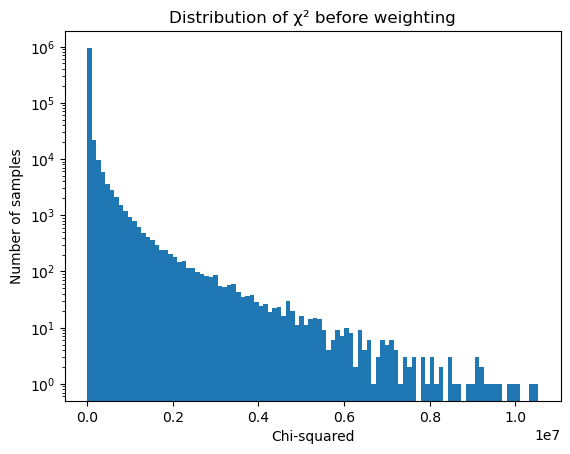

In [101]:
plt.hist(chisq, bins=100, log=True)
plt.xlabel('Chi-squared')
plt.ylabel('Number of samples')
plt.title('Distribution of χ² before weighting')
plt.show()

In [102]:
# Compute weights
weights = np.exp(-0.5 * chisq)
weights /= np.sum(weights)


In [103]:
print("Weights:", np.min(weights), np.max(weights), np.median(weights))
print("A1_sim median:", np.median(A1_sim))
print("A2_sim median:", np.median(A2_sim))

Weights: 0.0 0.0005610044587958111 1.8490999836481475e-157
A1_sim median: 0.010942079493312934
A2_sim median: 0.03407482956700321


In [104]:
from astropy.constants import M_earth
Mearth_to_Msun = M_earth.value / M_sun.value

# --- Convert to real units ---
M1_samples = mu1 * M_star / Mearth_to_Msun# Earth masses
M2_samples = mu2 * M_star / Mearth_to_Msun# Earth masses


In [105]:
# Weighted statistics function for credible intervals
def weighted_percentile(data, weights, percentiles):
    idx = np.argsort(data)
    data, weights = data[idx], weights[idx]
    cdf = np.cumsum(weights)
    cdf /= cdf[-1]
    return np.interp(percentiles, cdf, data)


In [106]:
Mb_lo, Mb_med, Mb_hi = weighted_percentile(M1_samples, weights, [0.16, 0.50, 0.84])
Mc_lo, Mc_med, Mc_hi = weighted_percentile(M2_samples, weights, [0.16, 0.50, 0.84])
Z_lo, Z_med, Z_hi   = weighted_percentile(Z_mag, weights, [0.16, 0.50, 0.84])

print(f"Mb = {Mb_med:.2f} (+{Mb_hi - Mb_med:.2f}/-{Mb_med - Mb_lo:.2f}) M_earth")
print(f"Mc = {Mc_med:.2f} (+{Mc_hi - Mc_med:.2f}/-{Mc_med - Mc_lo:.2f}) M_earth")
print(f"log10|Z_free| = {np.log10(Z_med):.2f} (+{np.log10(Z_hi) - np.log10(Z_med):.2f}/-{np.log10(Z_med) - np.log10(Z_lo):.2f})")

Mb = 3.19 (+0.40/-1.41) M_earth
Mc = 1.80 (+0.29/-0.89) M_earth
log10|Z_free| = -2.64 (+0.98/-0.93)


In [107]:
mu2_lo, mu2_med, mu2_hi = weighted_percentile(mu1, weights, [0.16, 0.50, 0.84])
print(f"mu2 = {mu2_med:.20f} (+{mu2_hi - mu2_med:.2f}/-{mu2_med - mu2_lo:.2f})")

mu2 = 0.00001183430529347631 (+0.00/-0.00)


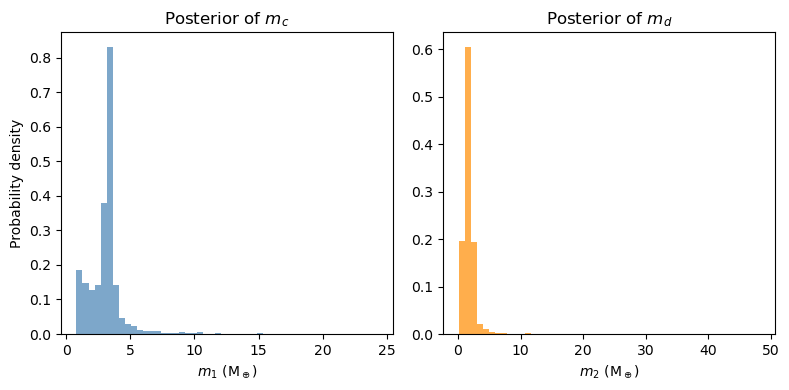

In [108]:
import matplotlib.pyplot as plt

# Convert to Earth masses


# Plot mass posterior for m1
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(M1_samples, bins=50, weights=weights, density=True, color='steelblue', alpha=0.7)
plt.xlabel(r"$m_1\ (\mathrm{M}_\oplus)$")
plt.ylabel("Probability density")
plt.title("Posterior of $m_c$")

# Plot mass posterior for m2
plt.subplot(1, 2, 2)
plt.hist(M2_samples, bins=50, weights=weights, density=True, color='darkorange', alpha=0.7)
plt.xlabel(r"$m_2\ (\mathrm{M}_\oplus)$")
plt.title("Posterior of $m_d$")

plt.tight_layout()
plt.show()


3.16 (+0.61/-1.22)
1.77 (+0.43/-0.82)


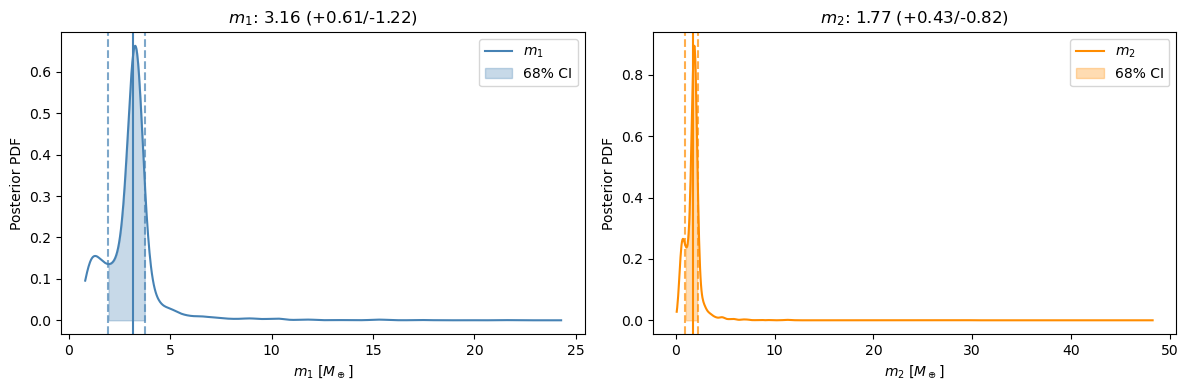

In [109]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

def plot_weighted_kde_with_ci(x, weights, label, color, ax):
    # Build weighted KDE
    kde = gaussian_kde(x, weights=weights)
    x_grid = np.linspace(np.min(x), np.max(x), 1000)
    pdf = kde(x_grid)

    # Normalize PDF
    pdf /= np.trapz(pdf, x_grid)

    # Compute CDF for confidence intervals
    cdf = np.cumsum(pdf) * (x_grid[1] - x_grid[0])

    # Compute 16th, 50th, 84th percentiles
    q16 = x_grid[np.searchsorted(cdf, 0.16)]
    q50 = x_grid[np.searchsorted(cdf, 0.50)]
    q84 = x_grid[np.searchsorted(cdf, 0.84)]

    # Plot KDE
    ax.plot(x_grid, pdf, color=color, label=label)
    ax.fill_between(x_grid, 0, pdf, where=(x_grid > q16) & (x_grid < q84), color=color, alpha=0.3, label='68% CI')

    # Plot vertical lines at quantiles
    ax.axvline(q16, color=color, linestyle='--', alpha=0.7)
    ax.axvline(q50, color=color, linestyle='-')
    ax.axvline(q84, color=color, linestyle='--', alpha=0.7)

    # Annotate median
    ax.set_title(f"{label}: {q50:.2f} (+{q84 - q50:.2f}/-{q50 - q16:.2f})")
    ax.set_xlabel(f"{label} [$M_\\oplus$]")
    ax.set_ylabel("Posterior PDF")
    ax.legend()

    print(f'{q50:.2f} (+{q84 - q50:.2f}/-{q50 - q16:.2f})')


# Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

plot_weighted_kde_with_ci(M1_samples, weights, r"$m_1$", "steelblue", axs[0])
plot_weighted_kde_with_ci(M2_samples, weights, r"$m_2$", "darkorange", axs[1])

plt.tight_layout()
plt.show()


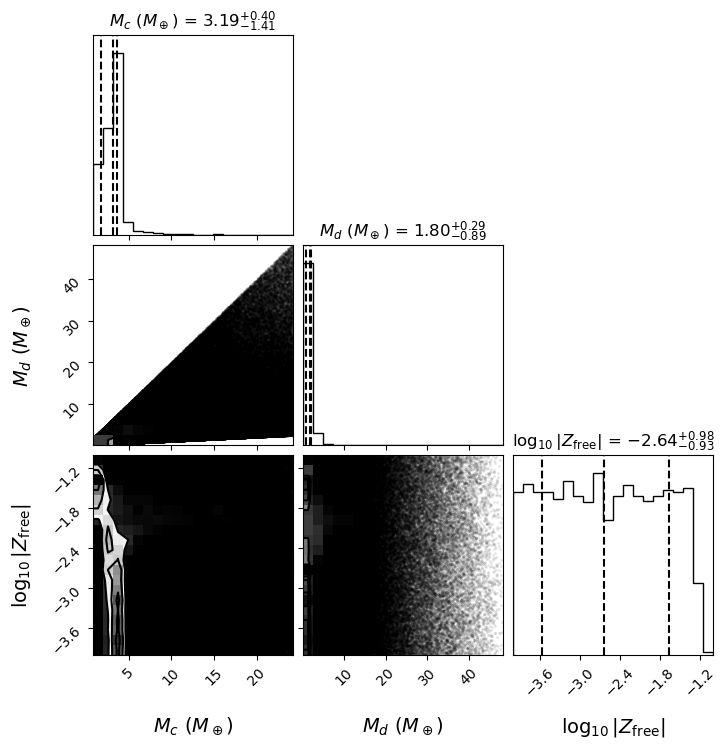

In [110]:
import corner
import numpy as np
import matplotlib.pyplot as plt

# Prepare the data array for the corner plot
samples = np.vstack([
    M1_samples,             # Mb in Earth masses
    M2_samples,             # Mc in Earth masses
    np.log10(Z_mag)         # log10|Z_free|
]).T  # shape: (N_samples, 3)

# Apply importance weights
# NOTE: corner does not natively support weights pre-2.1.0, so check version if needed
fig = corner.corner(
    samples,
    weights=weights,
    labels=[r"$M_c\ (M_\oplus)$", r"$M_d\ (M_\oplus)$", r"$\log_{10}|Z_{\rm free}|$"],
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14}
)

plt.show()


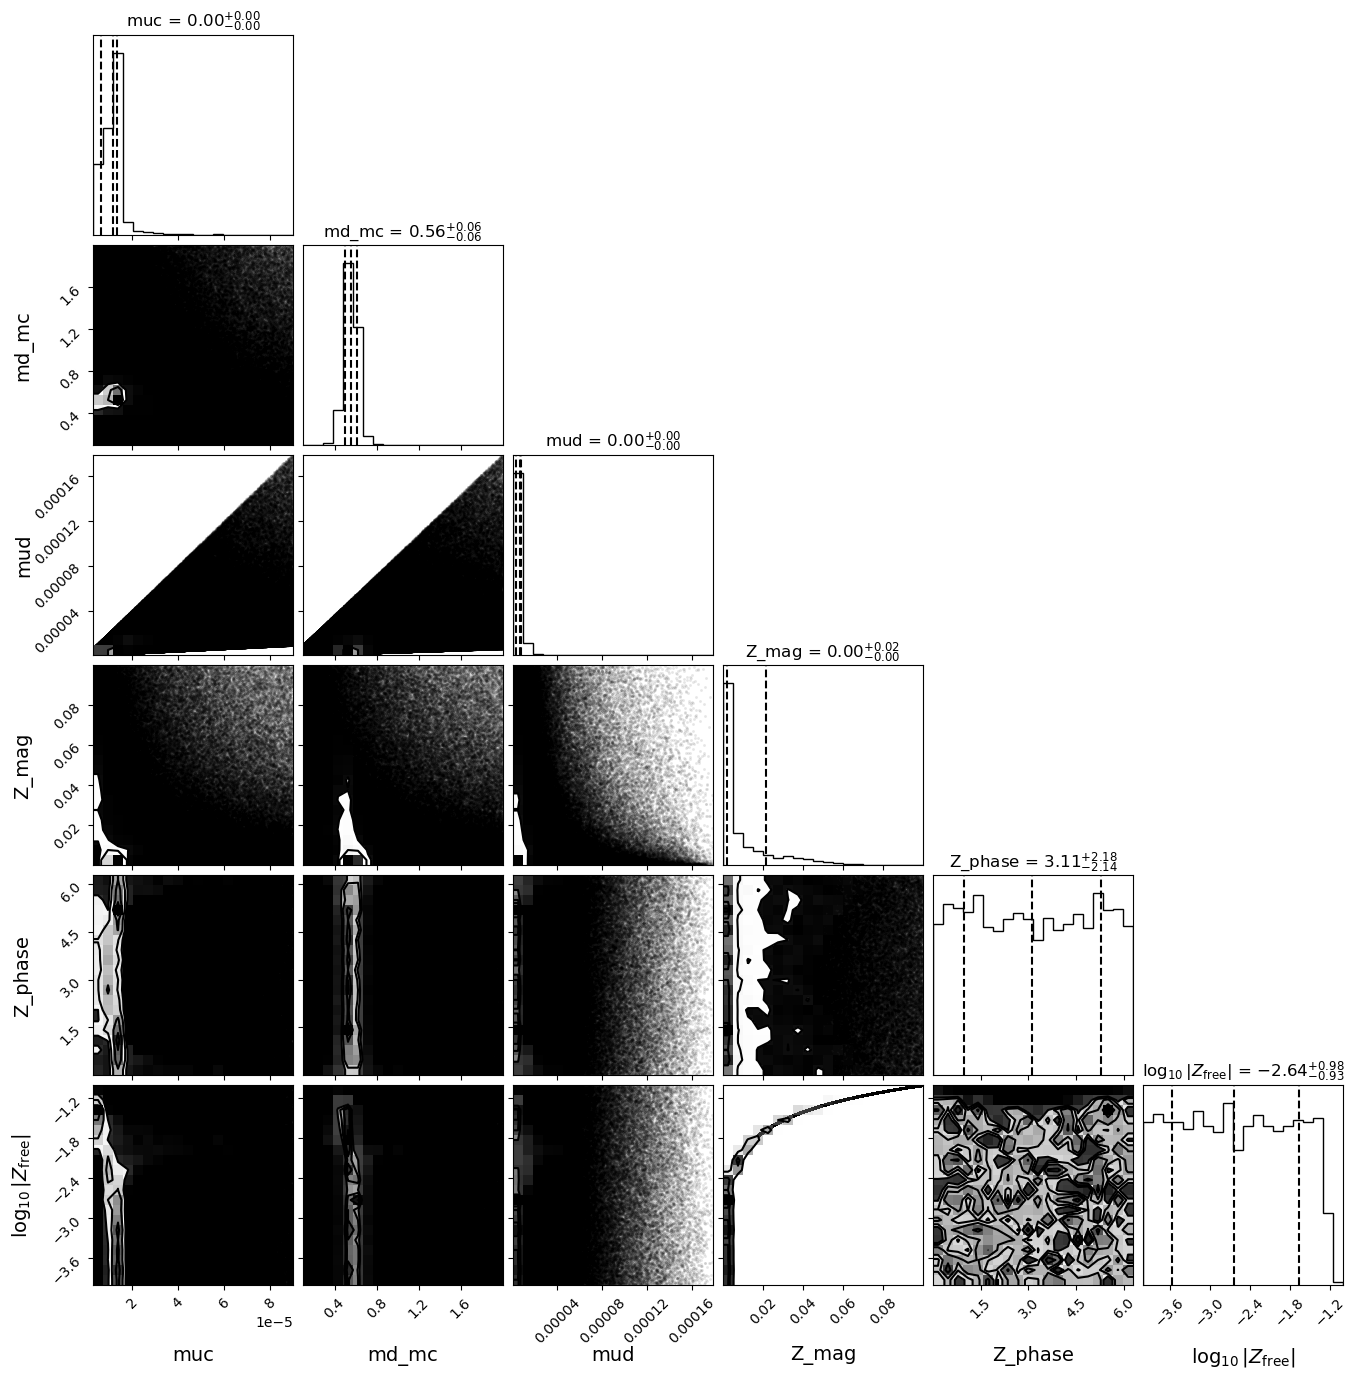

In [111]:
# Prepare the data array for the corner plot
samples = np.vstack([
    mu1,             
    m2_m1,
    mu2,
    Z_mag,
    Z_phase,
    np.log10(Z_mag)
]).T  # shape: (N_samples, 3)

# Apply importance weights
# NOTE: corner does not natively support weights pre-2.1.0, so check version if needed
fig = corner.corner(
    samples,
    weights=weights,
    labels=['muc', 'md_mc', 'mud', 'Z_mag', 'Z_phase', r"$\log_{10}|Z_{\rm free}|$"],
    show_titles=True,
    title_fmt=".2f",
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14}
)

plt.show()


## refit with best fit

In [112]:
# Assume you have already done a least-squares fit
best_mu1 = Mb_med * Mearth_to_Msun / M_star
best_mu2 = Mc_med * Mearth_to_Msun / M_star
best_Zmag = 10 ** np.log10(Z_med)

mu1 = log_uniform(best_mu1 / 10, best_mu1 * 10, N_samples)
m2_m1 = log_uniform(0.1, 2, N_samples)
mu2 = mu1 * m2_m1
Z_mag = log_uniform(best_Zmag / 10, best_Zmag * 10, N_samples)
Z_phase = np.random.uniform(0, 2*np.pi, N_samples)
Z_free = Z_mag * np.exp(1j * Z_phase)

In [113]:
A1_sim_complex = A_1_(P1, mu2, j, delta, f1, Z_free)
A2_sim_complex = A_2_(P2, mu1, j, delta, f2, Z_free)

# Simulated amplitudes and phase difference
A1_sim = np.abs(A1_sim_complex)
A2_sim = np.abs(A2_sim_complex)

phi_sim = np.angle(A2_sim_complex) - np.angle(A2_sim_complex)
phi_sim = (phi_sim + np.pi) % (2 * np.pi) - np.pi


In [114]:
# Compute chi-square
chisq = ((A1_sim - A1_obs)**2 / sigma_A1**2 +
         (A2_sim - A2_obs)**2 / sigma_A2**2 +
         (phi_sim - phi_obs)**2 / sigma_phi**2)


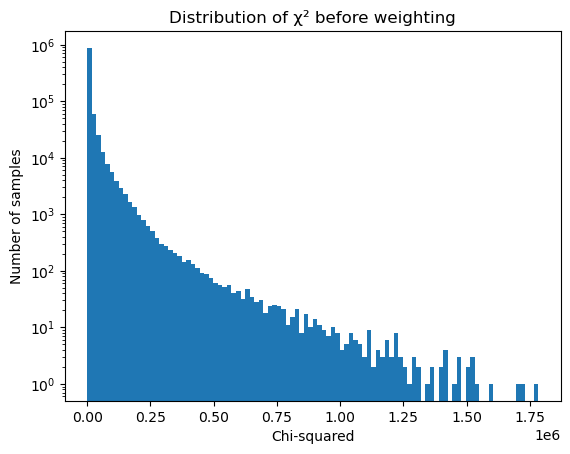

In [115]:
plt.hist(chisq, bins=100, log=True)
plt.xlabel('Chi-squared')
plt.ylabel('Number of samples')
plt.title('Distribution of χ² before weighting')
plt.show()

In [116]:
# Compute weights
weights = np.exp(-0.5 * chisq)
weights /= np.sum(weights)


In [117]:
print("Weights:", np.min(weights), np.max(weights), np.median(weights))
print("A1_sim median:", np.median(A1_sim))
print("A2_sim median:", np.median(A2_sim))

Weights: 0.0 0.0007183006119995712 2.1126793604417135e-111
A1_sim median: 0.006151049070116948
A2_sim median: 0.018978942220234662


In [118]:
M1_samples = mu1 * M_star / Mearth_to_Msun# Earth masses
M2_samples = mu2 * M_star / Mearth_to_Msun# Earth masses


In [119]:
Mb_lo, Mb_med, Mb_hi = weighted_percentile(M1_samples, weights, [0.16, 0.50, 0.84])
Mc_lo, Mc_med, Mc_hi = weighted_percentile(M2_samples, weights, [0.16, 0.50, 0.84])
Z_lo, Z_med, Z_hi   = weighted_percentile(Z_mag, weights, [0.16, 0.50, 0.84])

print(f"Mb = {Mb_med:.2f} (+{Mb_hi - Mb_med:.2f}/-{Mb_med - Mb_lo:.2f}) M_earth")
print(f"Mc = {Mc_med:.2f} (+{Mc_hi - Mc_med:.2f}/-{Mc_med - Mc_lo:.2f}) M_earth")
print(f"log10|Z_free| = {np.log10(Z_med):.2f} (+{np.log10(Z_hi) - np.log10(Z_med):.2f}/-{np.log10(Z_med) - np.log10(Z_lo):.2f})")

Mb = 3.24 (+0.60/-0.72) M_earth
Mc = 1.84 (+0.40/-0.48) M_earth
log10|Z_free| = -2.63 (+0.69/-0.67)


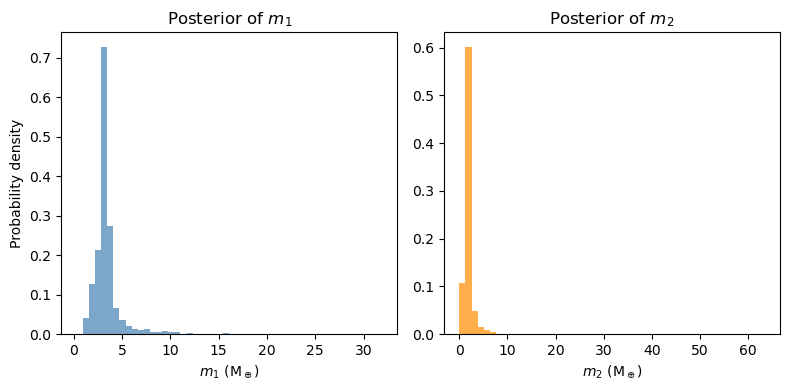

In [120]:
# Plot mass posterior for m1
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(M1_samples, bins=50, weights=weights, density=True, color='steelblue', alpha=0.7)
plt.xlabel(r"$m_1\ (\mathrm{M}_\oplus)$")
plt.ylabel("Probability density")
plt.title("Posterior of $m_1$")

# Plot mass posterior for m2
plt.subplot(1, 2, 2)
plt.hist(M2_samples, bins=50, weights=weights, density=True, color='darkorange', alpha=0.7)
plt.xlabel(r"$m_2\ (\mathrm{M}_\oplus)$")
plt.title("Posterior of $m_2$")

plt.tight_layout()
plt.show()


# Try mcmc

In [195]:
def log_prior(params):
    mu1, m2_m1, Z_mag, Z_phase = params

    if not (3e-6 < mu1 < 9e-5):
        return -np.inf
    if not (0.1 < m2_m1 < 2):
        return -np.inf
    if not (1e-4 < Z_mag < 1e-1):
        return -np.inf
    if not (0 <= Z_phase <= 2*np.pi):
        return -np.inf

    # Flat in log-space → log-uniform prior
    return -np.log(mu1) - np.log(m2_m1) - np.log(Z_mag)

def log_likelihood(params):
    mu1, m2_m1, Z_mag, Z_phase = params

    mu2 = mu1 * m2_m1
    Z_free = Z_mag * np.exp(1j * Z_phase)

    A1_sim_complex = A_1_(P1, mu2, j, delta, f1, Z_free)
    A2_sim_complex = A_2_(P2, mu1, j, delta, f2, Z_free)

    A1_sim = np.abs(A1_sim_complex)
    A2_sim = np.abs(A2_sim_complex)

    phi_sim = np.angle(A2_sim_complex) - np.angle(A1_sim_complex)
    phi_sim = (phi_sim + np.pi) % (2*np.pi) - np.pi

    chi2 = ((A1_sim - A1_obs)**2 / sigma_A1**2 +
            (A2_sim - A2_obs)**2 / sigma_A2**2)# +
            # (phi_sim - phi_obs)**2 / sigma_phi**2)

    return -0.5 * chi2

def log_posterior(params):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params)

In [196]:
import emcee
import numpy as np

ndim = 4
nwalkers = 32
nsteps = 10000

# Initial guess near likely values
initial = np.array([1e-5, 0.3, 0.01, np.pi])
p0 = initial + 1e-6 * np.random.randn(nwalkers, ndim)

# Create and run sampler
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
print("Running MCMC...")
sampler.run_mcmc(p0, nsteps, progress=True)


Running MCMC...


100%|███████████████████████████████████| 10000/10000 [00:03<00:00, 2704.96it/s]


State([[1.20754472e-05 5.66136619e-01 2.64807379e-04 6.42287799e-01]
 [1.29311174e-05 5.84402353e-01 1.37290969e-03 7.45402982e-01]
 [1.42584912e-05 5.22916243e-01 2.06332956e-03 4.59827928e-01]
 [1.05475008e-05 5.30071918e-01 3.19177768e-03 2.38483529e+00]
 [1.18272357e-05 5.78613458e-01 4.12060871e-04 3.99249471e+00]
 [1.21483992e-05 4.75939603e-01 2.17939000e-02 6.94147417e-01]
 [1.29410585e-05 4.94956091e-01 1.93924225e-04 2.93822746e+00]
 [7.57256431e-06 5.34032720e-01 9.95653844e-03 3.67347461e+00]
 [7.38473229e-06 4.62252951e-01 1.12525504e-02 3.23621352e+00]
 [1.46530944e-05 5.21815284e-01 2.12939324e-03 3.48380820e-01]
 [1.31158006e-05 5.36422006e-01 4.46490097e-04 1.31813573e+00]
 [8.04470204e-06 4.97682029e-01 1.24228866e-02 4.36057185e+00]
 [5.10863466e-06 4.39489304e-01 4.60605384e-02 5.90995716e+00]
 [1.52569477e-05 5.49347121e-01 3.40467552e-03 7.24628686e-01]
 [1.32396992e-05 4.82391748e-01 1.52620317e-03 1.49557962e+00]
 [1.28247223e-05 5.43687783e-01 5.19958640e-04 4.

In [197]:
samples = sampler.get_chain(discard=2000, thin=15, flat=True)

# Extract parameters
mu1_samples = samples[:, 0]
m2_m1_samples = samples[:, 1]
mu2_samples = mu1_samples * m2_m1_samples
Z_mag_samples = samples[:, 2]
Z_phase_samples = samples[:, 3]

# Convert to physical masses
from astropy.constants import M_earth, M_sun
Mearth_to_Msun = M_earth.value / M_sun.value
M1_samples = mu1_samples * M_star / Mearth_to_Msun
M2_samples = mu2_samples * M_star / Mearth_to_Msun

# Optional: log10(Z_mag)
logZ = np.log10(Z_mag_samples)


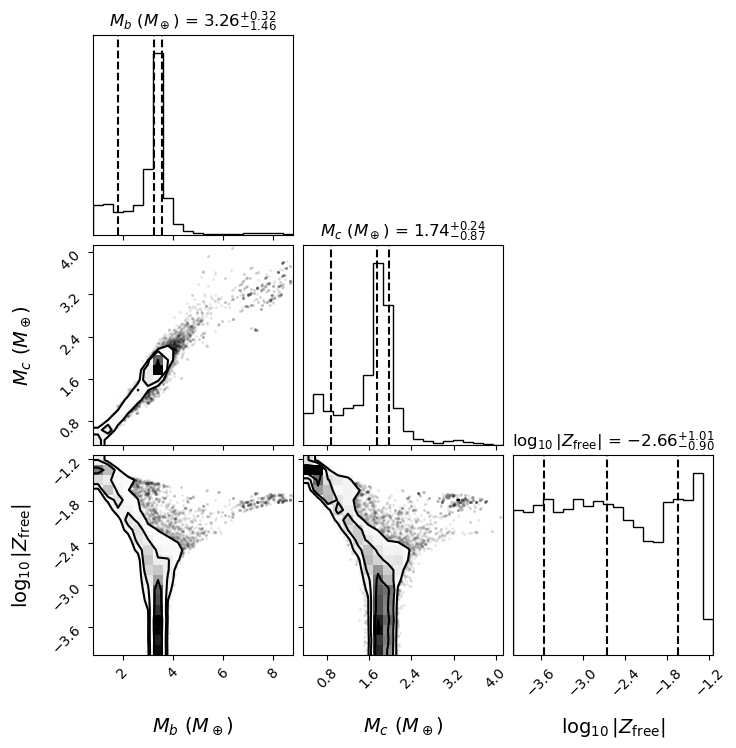

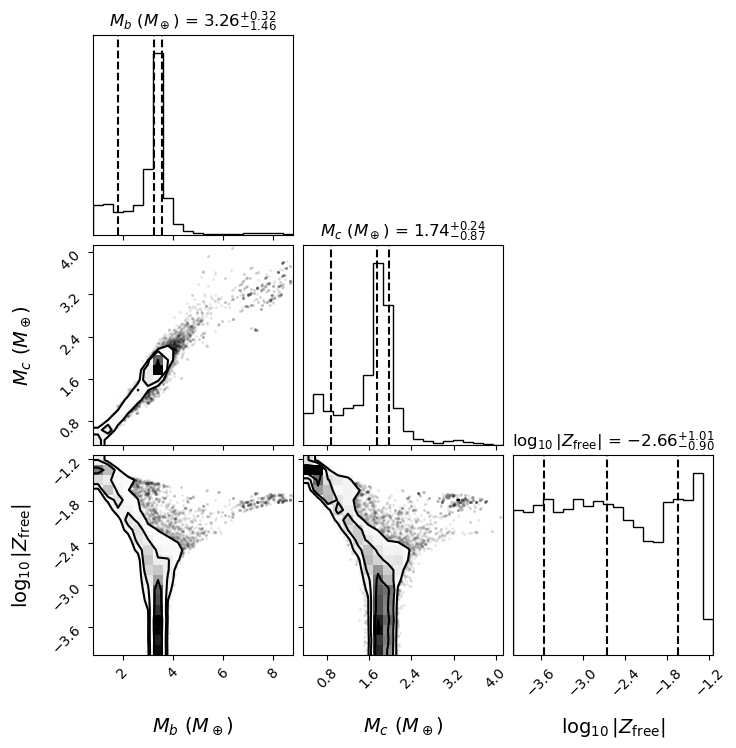

In [198]:
import corner

corner.corner(
    np.vstack([M1_samples, M2_samples, logZ]).T,
    labels=[r"$M_b\ (M_\oplus)$", r"$M_c\ (M_\oplus)$", r"$\log_{10}|Z_{\rm free}|$"],
    show_titles=True,
    quantiles=[0.16, 0.5, 0.84],
    title_fmt=".2f",
    title_kwargs={"fontsize": 12},
    label_kwargs={"fontsize": 14}
)


In [199]:
def credible_interval(x):
    q16, q50, q84 = np.percentile(x, [16, 50, 84])
    return f"{q50:.2f} (+{q84 - q50:.2f}/-{q50 - q16:.2f})"

print("Mb =", credible_interval(M1_samples), "M_earth")
print("Mc =", credible_interval(M2_samples), "M_earth")
print("log10|Z_free| =", credible_interval(logZ))


Mb = 3.26 (+0.32/-1.46) M_earth
Mc = 1.74 (+0.24/-0.87) M_earth
log10|Z_free| = -2.66 (+1.01/-0.90)


# try different model

In [118]:
def model_b(i_b, t_b0, P_b, B_bc, C_bc, P_cb, t_cb0):
    t_linear = t_b0 + P_b * i_b
    omega = 2 * np.pi / P_cb
    return t_linear + B_bc * np.sin(omega * (t_linear - t_cb0)) + C_bc * np.cos(omega * (t_linear - t_cb0))

def model_c(i_c, t_c0, P_c, B_cb, C_cb, P_cb, t_cb0):
    t_linear = t_c0 + P_c * i_c
    omega = 2 * np.pi / P_cb
    return t_linear + B_cb * np.sin(omega * (t_linear - t_cb0)) + C_cb * np.cos(omega * (t_linear - t_cb0))

def residuals(params, i_b, t_obs_b, err_b, i_c, t_obs_c, err_c):
    t_b0, P_b, B_bc, C_bc, t_c0, P_c, B_cb, C_cb, P_cb, t_cb0 = params

    t_model_b = model_b(i_b, t_b0, P_b, B_bc, C_bc, P_cb, t_cb0)
    t_model_c = model_c(i_c, t_c0, P_c, B_cb, C_cb, P_cb, t_cb0)

    res_b = (t_obs_b - t_model_b) / err_b
    res_c = (t_obs_c - t_model_c) / err_c

    return np.concatenate([res_b, res_c])

In [119]:
# Initial guesses for parameters
initial_t_b0 = tc_2
initial_P_b = p_2
initial_A_bc = .012    ####
initial_t_c0 = tc_3
initial_P_c = p_3
initial_A_cb =  0.2   ####
initial_P_cb = ttv_period
initial_t_cb0 = tc_3   ###
initial_B_bc = 0.01
initial_C_bc = 0.01
initial_B_cb = 0.2
initial_C_cb = 0.2

initial_params = [
    initial_t_b0, initial_P_b, initial_B_bc, initial_C_bc,
    initial_t_c0, initial_P_c, initial_B_cb, initial_C_cb,
    initial_P_cb, initial_t_cb0
]

In [120]:
result = least_squares(
    residuals,
    initial_params,
    args=(indices_2, transit_times_2, tc_err_2, indices_3, transit_times_3, tc_err_3),
    method='trf'
)

In [121]:
fitted_params = result.x
t_b0, P_b, B_bc, C_bc, t_c0, P_c, B_cb, C_cb, P_cb, t_cb0 = result.x


In [122]:
from numpy.linalg import inv

# Covariance matrix estimate
J = result.jac
cov = inv(J.T @ J)
param_errors = np.sqrt(np.diag(cov))
t_b0_err, P_b_err, B_bc_err, C_bc_err, t_c0_err, P_c_err, B_cb_err, C_cb_err, P_cb_err, t_cb0_err = param_errors


In [123]:
# Names of parameters in order
param_names = ["t_b0", "P_b", "B_bc", "C_bc", "t_c0", "P_c", "B_cb", "C_cb", "P_cb", "t_cb0"]

print("Fitted Parameters with 1σ Uncertainties:\n")
for name, val, err in zip(param_names, fitted_params, param_errors):
    print(f"{name:>6} = {val:.8f} ± {err:.8f}")


Fitted Parameters with 1σ Uncertainties:

  t_b0 = 1726.04658191 ± 0.00056527
   P_b = 28.58030734 ± 0.00001178
  B_bc = 0.00645994 ± 0.46504729
  C_bc = -0.00400585 ± 0.74974255
  t_c0 = 1743.57245669 ± 0.00090327
   P_c = 38.35125114 ± 0.00003635
  B_cb = -0.01884986 ± 0.66102317
  C_cb = 0.00569671 ± 2.18782591
  P_cb = 1528.14625134 ± 25.18006880
 t_cb0 = 1337.63147013 ± 28232.30317314


In [125]:
from numpy.linalg import eigh

# Covariance estimate (regularize if necessary)
J = result.jac
cov_raw = inv(J.T @ J)

# Force covariance to nearest PSD by eigenvalue clipping
eigvals, eigvecs = eigh(cov_raw)
eigvals_clipped = np.clip(eigvals, a_min=1e-12, a_max=None)
cov = (eigvecs @ np.diag(eigvals_clipped) @ eigvecs.T)

# Monte Carlo draw
n_mc = 5000
mc = np.random.multivariate_normal(fitted_params, cov, size=n_mc)

# Extract B,C samples for each planet
B_bc_samps = mc[:, 2]; C_bc_samps = mc[:, 3]
B_cb_samps = mc[:, 6]; C_cb_samps = mc[:, 7]

# Amplitudes and phases
A_bc_samps = np.hypot(B_bc_samps, C_bc_samps)
phi_b_samps = np.arctan2(C_bc_samps, B_bc_samps)

A_cb_samps = np.hypot(B_cb_samps, C_cb_samps)
phi_c_samps = np.arctan2(C_cb_samps, B_cb_samps)

# Observed differences
phi_obs_samps = (phi_c_samps - phi_b_samps + np.pi) % (2 * np.pi) - np.pi

# Summary statistics
A_bc = np.median(A_bc_samps); sigma_A_bc = np.std(A_bc_samps)
A_cb = np.median(A_cb_samps); sigma_A_cb = np.std(A_cb_samps)
phi_b = np.median(phi_b_samps); sigma_phi_b = np.std(phi_b_samps)
phi_c = np.median(phi_c_samps); sigma_phi_c = np.std(phi_c_samps)
phi_obs = np.median(phi_obs_samps); sigma_phi_obs = np.std(phi_obs_samps)

print(f"A_bc = {A_bc:.6f} ± {sigma_A_bc:.6f}")
print(f"A_cb = {A_cb:.6f} ± {sigma_A_cb:.6f}")
print(f"phi_b = {phi_b:.4f} ± {sigma_phi_b:.4f} rad")
print(f"phi_c = {phi_c:.4f} ± {sigma_phi_c:.4f} rad")
print(f"phi_obs = {phi_obs:.4f} ± {sigma_phi_obs:.4f} rad")


A_bc = 0.617068 ± 0.528121
A_cb = 1.598213 ± 1.368116
phi_b = -1.8404 ± 1.5364 rad
phi_c = 1.2812 ± 1.6130 rad
phi_obs = -2.8798 ± 0.0088 rad


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_68704/1019348214.py:14: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  mc = np.random.multivariate_normal(fitted_params, cov, size=n_mc)


/var/folders/69/wlx91x8s1x34mphlfjy0h4pm0000gn/T/ipykernel_68704/4263504540.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


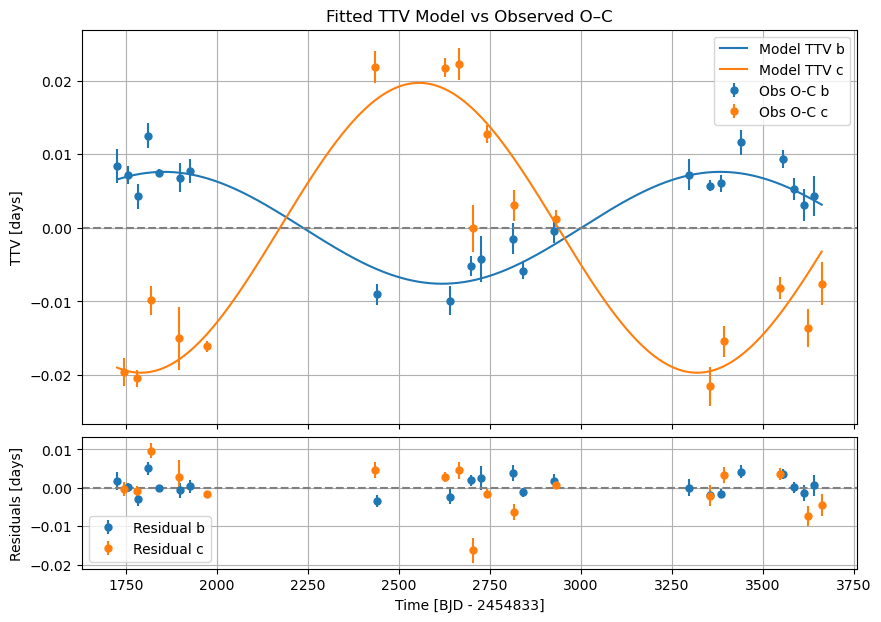

In [126]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Reconstruct linear ephemerides
t_dense = np.linspace(np.min(np.concatenate([transit_times_2, transit_times_3])),
                      np.max(np.concatenate([transit_times_2, transit_times_3])), 1000)
i_dense_b = (t_dense - t_b0) / P_b
i_dense_c = (t_dense - t_c0) / P_c
t_lin_b = t_b0 + P_b * i_dense_b
t_lin_c = t_c0 + P_c * i_dense_c

# TTV model (sinusoidal part) in days
omega = 2 * np.pi / P_cb
ttv_model_dense_b = B_bc * np.sin(omega * (t_lin_b - t_cb0)) + C_bc * np.cos(omega * (t_lin_b - t_cb0))
ttv_model_dense_c = B_cb * np.sin(omega * (t_lin_c - t_cb0)) + C_cb * np.cos(omega * (t_lin_c - t_cb0))

# Observed O-C
t_lin_obs_b = t_b0 + P_b * np.array(indices_2)
t_lin_obs_c = t_c0 + P_c * np.array(indices_3)
oc_b = np.array(transit_times_2) - t_lin_obs_b
oc_c = np.array(transit_times_3) - t_lin_obs_c

# Model at observed times
ttv_model_obs_b = B_bc * np.sin(omega * (t_lin_obs_b - t_cb0)) + C_bc * np.cos(omega * (t_lin_obs_b - t_cb0))
ttv_model_obs_c = B_cb * np.sin(omega * (t_lin_obs_c - t_cb0)) + C_cb * np.cos(omega * (t_lin_obs_c - t_cb0))

# Plot
fig = plt.figure(figsize=(10,7))
gs = GridSpec(2,1, height_ratios=[3,1], hspace=0.05)

# Top: TTVs
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_dense, ttv_model_dense_b, label="Model TTV b", color="tab:blue")
ax1.plot(t_dense, ttv_model_dense_c, label="Model TTV c", color="tab:orange")
ax1.errorbar(t_lin_obs_b, oc_b, yerr=tc_err_2, fmt="o", color="tab:blue", label="Obs O-C b", markersize=5)
ax1.errorbar(t_lin_obs_c, oc_c, yerr=tc_err_3, fmt="o", color="tab:orange", label="Obs O-C c", markersize=5)
ax1.axhline(0, linestyle="--", color="gray")
ax1.set_ylabel("TTV [days]")
ax1.set_title("Fitted TTV Model vs Observed O–C")
ax1.legend()
ax1.tick_params(labelbottom=False)
ax1.grid(True)

# Bottom: residuals (observed minus model)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
res_b = oc_b - ttv_model_obs_b
res_c = oc_c - ttv_model_obs_c
ax2.errorbar(t_lin_obs_b, res_b, yerr=tc_err_2, fmt="o", color="tab:blue", label="Residual b", markersize=5)
ax2.errorbar(t_lin_obs_c, res_c, yerr=tc_err_3, fmt="o", color="tab:orange", label="Residual c", markersize=5)
ax2.axhline(0, linestyle="--", color="gray")
ax2.set_xlabel("Time [BJD - 2454833]")
ax2.set_ylabel("Residuals [days]")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


In [127]:
A_bc = np.sqrt(B_bc**2 + C_bc**2)
phi_b = np.arctan2(C_bc, B_bc)

A_cb = np.sqrt(B_cb**2 + C_cb**2)
phi_c = np.arctan2(C_cb, B_cb)

phi_obs = (phi_c - phi_b + np.pi) % (2 * np.pi) - np.pi

print(A_bc)
print(A_cb)
print(phi_b)
print(phi_c)
print(phi_obs)

0.0076011571984901495
0.019691864173044464
-0.5550727346399954
2.848105138086124
-2.880007434453466


In [128]:
import numpy as np

def error_propagation_amplitude_phase(B, C, cov_BC):
    A = np.sqrt(B**2 + C**2)
    
    # Gradient vectors
    grad_A = np.array([B / A, C / A])
    grad_phi = np.array([-C / A**2, B / A**2])
    
    # Variances
    var_A = grad_A @ cov_BC @ grad_A
    var_phi = grad_phi @ cov_BC @ grad_phi
    
    sigma_A = np.sqrt(var_A)
    sigma_phi = np.sqrt(var_phi)
    
    return A, sigma_A, np.arctan2(C, B), sigma_phi

# Example with your fitted parameters & covariance submatrix
# Extract covariance submatrices for (B_bc, C_bc) and (B_cb, C_cb)
# assuming indices 2,3 and 6,7 in cov matrix

cov_BC_bc = cov[2:4, 2:4]
cov_BC_cb = cov[6:8, 6:8]

# Fitted parameters
B_bc_val, C_bc_val = fitted_params[2], fitted_params[3]
B_cb_val, C_cb_val = fitted_params[6], fitted_params[7]

A_bc, sigma_A_bc, phi_b, sigma_phi_b = error_propagation_amplitude_phase(B_bc_val, C_bc_val, cov_BC_bc)
A_cb, sigma_A_cb, phi_c, sigma_phi_c = error_propagation_amplitude_phase(B_cb_val, C_cb_val, cov_BC_cb)

print(f"A_bc = {A_bc:.6f} ± {sigma_A_bc:.6f}")
print(f"phi_b = {phi_b:.4f} ± {sigma_phi_b:.4f} rad")
print(f"A_cb = {A_cb:.6f} ± {sigma_A_cb:.6f}")
print(f"phi_c = {phi_c:.4f} ± {sigma_phi_c:.4f} rad")

# For phase difference error (phi_obs):
# assuming phi_obs = (phi_c - phi_b) wrapped in [-pi, pi],
# and phi_b and phi_c independent (approx):

sigma_phi_obs = np.sqrt(sigma_phi_b**2 + sigma_phi_c**2)
phi_obs = (phi_c - phi_b + np.pi) % (2 * np.pi) - np.pi

print(f"phi_obs = {phi_obs:.4f} ± {sigma_phi_obs:.4f} rad")


A_bc = 0.007601 ± 0.000448
phi_b = -0.5551 ± 116.0692 rad
A_cb = 0.019692 ± 0.000696
phi_c = 2.8481 ± 116.0634 rad
phi_obs = -2.8800 ± 164.1425 rad
